<a href="https://colab.research.google.com/github/francji1/01RAD/blob/main/code/01RAD_Ex01_HW.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01RAD - Homework 01: Cars braking distance

Investigate the relationship between the speed of a car and its stopping distance using the classic `cars` dataset (50 observations recorded in the 1920s: `speed` in mph, `dist` in ft).

Use the notation of Lecture 1: model $Y_i = \beta_0 + \beta_1 x_i + e_i$, least squares estimates $\widehat{\beta}_0, \widehat{\beta}_1$, residuals $\widehat{e}_i$, unbiased variance estimate $s_n^2 = SSE/(n-2)$.

## Submission
Work through the tasks below in this notebook (code plus short written answers in markdown cells). Python is the default, but you may equally solve the tasks in R (`lm(dist ~ speed, data = cars)`), the questions are the same.

Submit your solution through GitHub **before the next exercise**:
1. fork the course repository `francji1/01RAD`,
2. save your notebook into the `HW/` folder as `01RAD_Ex01_HW_<Surname>.ipynb` (for example `01RAD_Ex01_HW_Novak.ipynb`; for a team join the surnames with an underscore),
3. open a pull request to the `main` branch of `francji1/01RAD`.

A selected student solution and a reference solution will be published in the `HW/` folder a week later.

## Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

sns.set_theme(style='whitegrid', palette='deep')

url_cars = 'https://raw.githubusercontent.com/francji1/01RAD/main/data/cars.csv'
try:
    cars = pd.read_csv(url_cars)
except Exception:
    # fallback: the same data set from R's datasets package via statsmodels
    cars = sm.datasets.get_rdataset('cars', package='datasets').data
print(f'Rows: {cars.shape[0]}, columns: {cars.shape[1]}')
cars.head()

Rows: 50, columns: 2


,speed,dist
0,4,2
1,4,10
2,7,4
3,7,22
4,8,16


## Task 01 - Inspect the data
Inspect the structure of the dataset (`info()`, `describe()`). Which variable is the response and which the explanatory variable here, and why?

In [2]:
# your solution
cars.info()
cars.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   speed   50 non-null     int64
 1   dist    50 non-null     int64
dtypes: int64(2)
memory usage: 932.0 bytes


,speed,dist
count,50.000000,50.000000
mean,15.400000,42.980000
std,5.287644,25.769377
min,4.000000,2.000000
25%,12.000000,26.000000
50%,15.000000,36.000000
75%,19.000000,56.000000
max,25.000000,120.000000


Vysvětlující veličinou je rychlost (speed) a vysvětlovanou je vzdálenost (dist), protože brzdná dráha závisí na rychlosti, kterou auto jede.

## Task 02 - Plots
Plot histograms with density curves for `speed` and `dist`, and the scatter plot of `dist` against `speed`. Comment on the shape of the relationship.

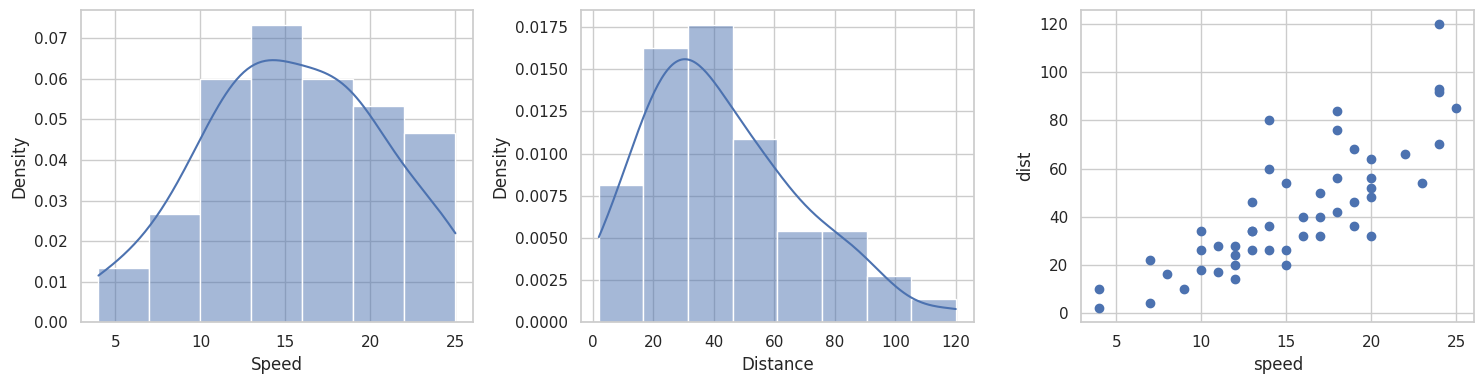

In [3]:

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(cars["speed"], kde=True, stat="density", ax=ax[0])
ax[0].set_xlabel("Speed")

sns.histplot(cars["dist"], kde=True, stat="density", ax=ax[1])
ax[1].set_xlabel("Distance")

ax[2].scatter(cars["speed"], cars["dist"])
ax[2].set_xlabel("speed"); ax[2].set_ylabel("dist")

plt.tight_layout()

Rozdeleni rychlosti je podle grafu unimodalni a priblizne symetricke. Graf pro vzdalenost ukazuje, ze ma vice malych a strednich hodnot a mene vysokych hodnot, rozdeleni neni symetricke. Z posledniho grafu je toho videt nejvice, zavislost brzdné dráhy na rychlosti je kladná, přibližně lineární a lehce prohnuty nahoru pri vyssich rychlostech se vice zvysi drah. Je take videt ze s rostouci rychlosti take vice roste rozptyl.

## Task 03 - Least squares by hand
Fit the simple linear regression model manually, both with intercept ($Y_i = \beta_0 + \beta_1 x_i + e_i$) and without intercept ($Y_i = \beta_1 x_i + e_i$, regression through the origin). Derive $\widehat{\beta}_0$ and $\widehat{\beta}_1$ from the sums (Lecture 1, formula (2.1)); for the model without intercept derive the estimate from its single normal equation. *Hint:* minimising $\sum_i (y_i - \beta_1 x_i)^2$ gives $\widehat{\beta}_1 = \sum_i x_i y_i / \sum_i x_i^2$, see Exercise 01, section 8.

In [4]:
x=cars["speed"].values
y=cars["dist"].values
n=len(x)

Sxx=np.sum(x**2)
Sxy=np.sum(x*y)
Sx=np.sum(x)
Sy=np.sum(y)

b1 = (n * Sxy - Sx * Sy) / (n * Sxx - Sx**2)
b0 = Sy / n - b1 * Sx / n

b1_0 = Sxy / Sxx

print(f"With intercept:    b0 = {b0:.4f}, b1 = {b1:.4f}")
print(f"Through origin:    b1 = {b1_0:.4f}")

With intercept:    b0 = -17.5791, b1 = 3.9324
Through origin:    b1 = 2.9091


**Model s interceptem:** podle vzorce
$$\hat\beta_1 = \frac{n\sum_i x_i y_i - \sum_i x_i \sum_i y_i}{n\sum_i x_i^2 - \left(\sum_i x_i\right)^2}, \qquad \hat\beta_0 = \bar y - \hat\beta_1 \bar x.$$

**Model bez interceptu:** minimalizujeme
$$S(\beta_1) = \sum_i (y_i - \beta_1 x_i)^2.$$
Derivace podle $\beta_1$ položená rovna nule dává normální rovnici
$$\frac{\partial S}{\partial \beta_1} = -2\sum_i x_i (y_i - \beta_1 x_i) = 0 \quad\Rightarrow\quad \sum_i x_i y_i = \beta_1 \sum_i x_i^2,$$
odkud
$$\hat\beta_1 = \frac{\sum_i x_i y_i}{\sum_i x_i^2}.$$

## Task 04 - Residual sum of squares and $s_n^2$
Compute the residual sum of squares $SSE$ and the unbiased estimate of the error variance for each model. Mind the degrees of freedom: $n-2$ with intercept, $n-1$ without.

In [5]:

yhat_1 = b0 + b1 * x      # s interceptem
yhat_0 = b1_0 * x         # bez interceptu


res_1 = y - yhat_1
res_0 = y - yhat_0


SSE_1 = np.sum(res_1**2)
SSE_0 = np.sum(res_0**2)


s2_1 = SSE_1 / (n - 2)
s2_0 = SSE_0 / (n - 1)

print(f"With intercept: SSE = {SSE_1:.2f}, s2 = {s2_1:.2f}, s = {np.sqrt(s2_1):.2f}")
print(f"Through origin: SSE = {SSE_0:.2f}, s2 = {s2_0:.2f}, s = {np.sqrt(s2_0):.2f}")

With intercept: SSE = 11353.52, s2 = 236.53, s = 15.38
Through origin: SSE = 12953.78, s2 = 264.36, s = 16.26


## Task 05 - Standard errors
Derive the estimated variances and standard errors of the estimated parameters in both models. Check them against `statsmodels` (`.bse`). *Hint:* for the model with intercept use the formulas previewed in Exercise 01, section 7; for the model through the origin $\mathrm{Var}(\widehat{\beta}_1) = \sigma^2 / \sum_i x_i^2$, with $\sigma^2$ estimated by $s_n^2$ on $n-1$ degrees of freedom.

In [12]:
xbar = np.mean(x)
Sxx_c = np.sum((x - xbar)**2)

# s interceptem
var_b1 = s2_1 / Sxx_c
var_b0 = s2_1 * (1/n + xbar**2 / Sxx_c)
se_b1 = np.sqrt(var_b1)
se_b0 = np.sqrt(var_b0)

# bez interceptu
var_b1_0 = s2_0 / np.sum(x**2)
se_b1_0 = np.sqrt(var_b1_0)

print(f"With intercept: SE(b0) = {se_b0:.4f}, SE(b1) = {se_b1:.4f}")
print(f"Through origin: SE(b1) = {se_b1_0:.4f}")
print(f"With intercept: Var(b0) = {var_b0:.4f}, Var(b1) = {var_b1:.4f}")
print(f"Through origin: Var(b1) = {var_b1_0:.4f}")
print(smf.ols("dist ~ speed", data=cars).fit().bse)
print(smf.ols("dist ~ speed - 1", data=cars).fit().bse)

With intercept: SE(b0) = 6.7584, SE(b1) = 0.4155
Through origin: SE(b1) = 0.1414
With intercept: Var(b0) = 45.6765, Var(b1) = 0.1727
Through origin: Var(b1) = 0.0200
Intercept    6.758440
speed        0.415513
dtype: float64
speed    0.141369
dtype: float64


## Task 06 - Fitted lines
Plot the data together with both fitted regression lines on the same axes.

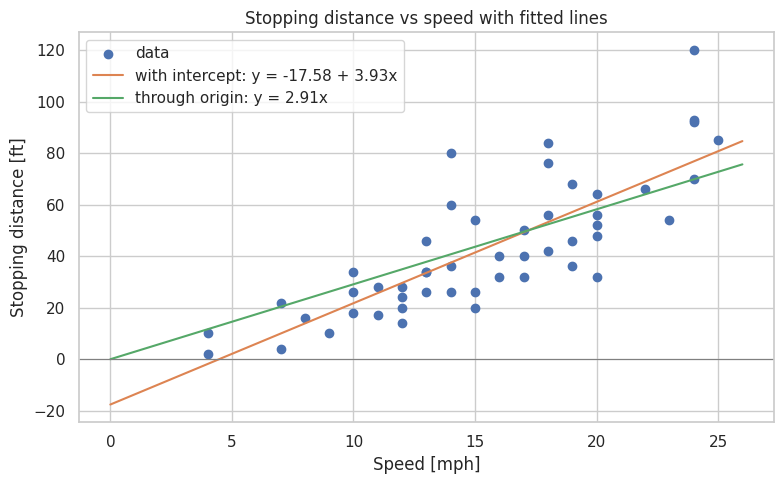

In [7]:
xs = np.linspace(0, 26, 200)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(x, y, label="data")
ax.plot(xs, b0 + b1 * xs, color="C1", label=f"with intercept: y = {b0:.2f} + {b1:.2f}x")
ax.plot(xs, b1_0 * xs, color="C2", label=f"through origin: y = {b1_0:.2f}x")
ax.axhline(0, color="gray", linewidth=0.8)
ax.set_xlabel("Speed [mph]")
ax.set_ylabel("Stopping distance [ft]")
ax.set_title("Stopping distance vs speed with fitted lines")
ax.legend()
plt.tight_layout()
plt.show()

## Task 07 - Compare the slopes
Compare the two slopes. Why do they differ? Which model makes more physical sense for braking distance, and what does the sign of $\widehat{\beta}_0$ tell you?

1. model s interceptem: y = -17.58 + 3.93x
2. model bez interceptu: y = 2.91x

Aby 1. model lépe procházel body vzdálenými od nuly, je přímka strmější a intercept je záporný, což naznačuje, že skutečný vztah není lineární.
2. model musí procházet bodem (0,0) a tak je růst přímky pomalejší. Fyzikálně je 2. model rozumnější, protože s nulovou rychlostí je nulová i brzdná dráha a ne záporná. Záporný intercept je tedy pouze statistický kompromis.

## Task 08 - Prediction
Predict the stopping distance at 20 mph and 30 mph with both models. Are the predictions plausible? Which one is an extrapolation?

In [8]:
# your solution

for v in [20, 30]:
    pred_A = b0 + b1 * v
    pred_B = b1_0 * v
    print(f"{v} mph: 1. model = {pred_A:.1f} ft, 2. model = {pred_B:.1f} ft")

20 mph: 1. model = 61.1 ft, 2. model = 58.2 ft
30 mph: 1. model = 100.4 ft, 2. model = 87.3 ft


Vzhledem k tomu, že rozsah rychlosti v datasetu je 4-25 mph, má předpověd pro 20 mph dostatek pozorování kolem této rychlosti. Oba modely dávají podobné výsledky a odpovídají tomu co můžeme vidět i na reálných datech.

Predikce pro 30 mph je extrapolace, protože je mimo rozsah dat a nemáme okolo této rychlosti data, o které by se model opřel. Z naměřených dat je vidět, že již pro rychlosti kolem 25 mph dosahuje brzdná dráha 120 ft, takže to vypadá, že oba modely podhodnocují.

## Task 09 - Residuals
Compute and plot the residuals $\widehat{e}_i$ against the fitted values for both models. Which residual pattern looks healthier, and what does the pattern suggest?

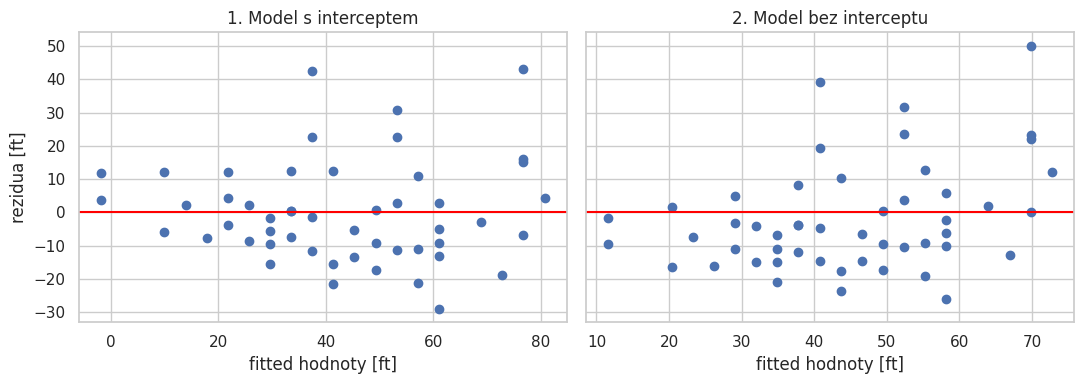

Průměr reziduí 1. modelu: 0.0  2. modelu: -1.821


In [9]:
# your solution

fit_A = b0 + b1 * x
fit_B = b1_0 * x
res_A = y - fit_A
res_B = y - fit_B

fig, ax = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for a, f, r, t in [(ax[0], fit_A, res_A, "1. Model s interceptem"),
                   (ax[1], fit_B, res_B, "2. Model bez interceptu")]:
    a.scatter(f, r)
    a.axhline(0, color="red", linestyle="-")
    a.set_title(t); a.set_xlabel("fitted hodnoty [ft]")
ax[0].set_ylabel("rezidua [ft]")
plt.tight_layout()
plt.show()

print("Průměr reziduí 1. modelu:", res_A.mean().round(3), " 2. modelu:", res_B.mean().round(3))

Rozptyl reziduí vypadá vyrovnaněji u 1. modelu. 2. model u nízkých rychlostí jsou chyby více záporné (model dráhu nadhodnocuje $(ê_i=y_i-ŷ_i)$) a u vysokých rychlostí kladné (podhodnocuje), jejich průměr navíc není nulový.  U obou modelu se rozptyl reziduí rozšiřuje, tudíž lineární model není pro daná data ideální.

## Task 10 - An artificial outlier
Add one artificial outlier (for example a large stopping distance at a low speed) and refit both models. How do the coefficients change? Which model is more sensitive?

In [14]:
# your solution
# přidám jeden umělý bod 5 mph, 100 ft
x_o = np.append(x, 5)
y_o = np.append(y, 100)
n_o = len(x_o)

Sxx_o, Sxy_o = np.sum(x_o**2), np.sum(x_o*y_o)
Sx_o, Sy_o = np.sum(x_o), np.sum(y_o)

b1_o = (n_o*Sxy_o - Sx_o*Sy_o) / (n_o*Sxx_o - Sx_o**2)
b0_o = Sy_o/n_o - b1_o*Sx_o/n_o
b1_0_o = Sxy_o / Sxx_o

print(f"S interceptem: b0 {b0:.2f} -> {b0_o:.2f},  b1 {b1:.3f} -> {b1_o:.3f}")
print(f"Bez interceptu:  b1 {b1_0:.3f} -> {b1_0_o:.3f}")

S interceptem: b0 -17.58 -> -5.38,  b1 3.932 -> 3.256
Bez interceptu:  b1 2.909 -> 2.941


Jeden takový bod pohnul sklonem modelu s interceptem velmi významně ($\hat\beta_1$ z $3{,}93$ na $3{,}26$, $\hat\beta_0$ z $-17{,}58$ na $-5{,}38$), zatímco sklon modelu bez interceptu se skoro nezměnil ($\hat\beta_1$ z $2{,}91$ na $2{,}94$). Je tedy vidět, že 1. model je na odlehlé hodnoty citlivější, protože prochází bodem $(\bar x, \bar y)$ a bod takto vzdálený od průměru $\bar x$ ho výrazně ovlivní. Model bez interceptu je ukotven v bodě $(0, 0)$ a bod s rychlostí tak blízko nuly ho tolik neovlivní.

## Task 11 - Is a straight line adequate?
Reflect on whether a straight-line model in `speed` is an adequate description. Physics suggests that braking distance grows with the square of speed. Suggest at least two possible next steps (a transformation of a variable, an additional term, ...) and try one of them. Transformations and checking model adequacy are the subject of later lectures; a short reflection and one experiment are enough here.

Přímka v rychlosti (speed) není adekvátní, protože vede k fyzikálně nesmyslnému zápornému interceptu a rezidua v task 9. vykazují zakřivení.

Možným řešením může být přidání kvadratického členu: $y = b_1x + b_2x^2$.
Další možnost je použít $\sqrt{y} = b_0 + b_1x$.

Ukázka prvního upraveného řešení.




dist = 1.239*v + 0.0901*v^2
SSE přímka: 11354  SSE kvadratický: 10831


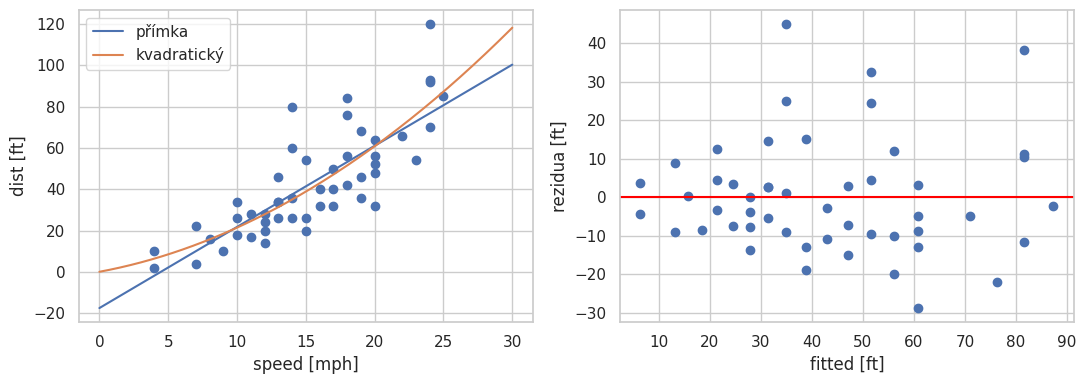

In [17]:
# your solution

X = np.column_stack([x, x**2])
(c1, c2), *_ = np.linalg.lstsq(X, y, rcond=None)
print(f"dist = {c1:.3f}*v + {c2:.4f}*v^2")

fit_lin = b0 + b1*x
fit_q = c1*x + c2*x**2
print("SSE přímka:", round(np.sum((y-fit_lin)**2)), " SSE kvadratický:", round(np.sum((y-fit_q)**2)))


v_grid = np.linspace(0, 30, 200)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].scatter(x, y)
ax[0].plot(v_grid, b0+b1*v_grid, label="přímka")
ax[0].plot(v_grid, c1*v_grid+c2*v_grid**2, label="kvadratický")
ax[0].set_xlabel("speed [mph]"); ax[0].set_ylabel("dist [ft]"); ax[0].legend()
ax[1].scatter(fit_q, y-fit_q); ax[1].axhline(0, color="red", ls="-")
ax[1].set_xlabel("fitted [ft]"); ax[1].set_ylabel("rezidua [ft]")
plt.tight_layout(); plt.show()

Kvadratický model bez interceptu prochází počátkem a lépe modeluje zakřivení dat, odpovídá tedy fyzikálnímu předpokladu lépe než přímka. Rezidua se zmenší, ale pořád zůstavá to, že se jejich rozptyl zvětšuje.
